# Plots

Este cuaderno se utiliza para crear gráficos complementarios necesarios en la memoria. La gran mayoría del código es rehusado de otros *notebooks*.

In [1]:
import json
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import average_precision_score, precision_recall_curve
from tensorflow.keras import Model
from tensorflow.keras.layers import (BatchNormalization, Concatenate, Conv1D, Dense,
                                     Dropout, GlobalAveragePooling1D, GlobalMaxPooling1D,
                                     Input, Lambda, ReLU, Softmax, SpatialDropout1D)
from xgboost import XGBClassifier

import utils
from config import MIN_CONSECUTIVE_DAYS as M_C, SEED
from feature_selection import apply_boruta_filtering
from modeling import evaluate_best_model, load_optuna_params
from utils import stratified_train_val_test_split

warnings.simplefilter("ignore", FutureWarning)
tf.random.set_seed(SEED)
np.random.seed(SEED)


## 1. Gráfico Precision-Recall

### Datos para el modelo DL


In [ ]:
def preprocess_raw_dataset(path, n=M_C, max_gap=670):
    df = pd.read_csv(path)
    df = (df
        .pipe(utils.drop_industrial_client)
        .pipe(utils.drop_clientID)
        .pipe(utils.drop_duplicated_rows)
        .pipe(utils.drop_inactive_clients)
        .pipe(utils.drop_n_not_consecutive_values, n=n)
        .pipe(utils.drop_large_max_gaps, max_gap_threshold=max_gap)
        .pipe(utils.interpolate_spikes)
    )
    df = df.interpolate(method='linear', limit_direction='both', limit_area='inside', limit=7)

    return df


def prepare_dl_data(df, random_seed=SEED):
    train_df, val_df, test_df = utils.stratified_train_val_test_split(df, random_state=random_seed)

    cols = df.columns[:-1]
    lower = train_df[cols].quantile(0.01)
    upper = train_df[cols].quantile(0.99)
    train_df[cols] = train_df[cols].clip(lower=lower, upper=upper, axis=1)
    val_df[cols] = val_df[cols].clip(lower=lower, upper=upper, axis=1)
    test_df[cols] = test_df[cols].clip(lower=lower, upper=upper, axis=1)

    X_train = train_df.drop(columns=['FLAG']).values
    y_train = train_df['FLAG'].values
    X_val = val_df.drop(columns=['FLAG']).values
    y_val = val_df['FLAG'].values
    X_test = test_df.drop(columns=['FLAG']).values
    y_test = test_df['FLAG'].values

    mean = np.nanmean(X_train, axis=0)
    std = np.nanstd(X_train, axis=0)
    std[std == 0] = 1.0

    X_train_scaled = (X_train - mean) / std
    X_val_scaled = (X_val - mean) / std
    X_test_scaled = (X_test - mean) / std

    mask_train = (~np.isnan(X_train)).astype(float)
    mask_val = (~np.isnan(X_val)).astype(float)
    mask_test = (~np.isnan(X_test)).astype(float)

    X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0)
    X_val_scaled = np.nan_to_num(X_val_scaled, nan=0.0)
    X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0)

    X_train_dl = np.stack((X_train_scaled, mask_train), axis=-1)
    X_val_dl = np.stack((X_val_scaled, mask_val), axis=-1)
    X_test_dl = np.stack((X_test_scaled, mask_test), axis=-1)

    return X_train_dl, X_val_dl, X_test_dl, y_train, y_val, y_test


df_path = 'data/dataset.csv'
df_dl = preprocess_raw_dataset(df_path, n=M_C, max_gap=670)
X_train_dl, X_val_dl, X_test_dl, y_train_dl, y_val_dl, y_test_dl = prepare_dl_data(df_dl, SEED)

### Carga del modelo de DL


In [3]:
def build_loaded_dl_model(input_shape):
    inputs = Input(shape=input_shape)

    branches = []
    for k in [7, 31, 91, 365]:
        b = Conv1D(32, k, padding='same')(inputs)
        b = BatchNormalization()(b)
        b = ReLU()(b)
        b = SpatialDropout1D(0.2)(b)
        branches.append(b)

    x = Concatenate()(branches)
    x = Conv1D(64, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    avg_pool = GlobalAveragePooling1D()(x)
    max_pool = GlobalMaxPooling1D()(x)
    score = Dense(1, activation='tanh')(x)
    attention_weights = Softmax(axis=1, name='attention_weights')(score)
    context = Lambda(
        lambda t: tf.reduce_sum(t[0] * t[1], axis=1),
        output_shape=(64,),
    )([x, attention_weights])

    combined = Concatenate()([avg_pool, max_pool, context])
    x = Dense(64, activation='relu')(combined)
    x = Dropout(0.5)(x)
    outputs = Dense(1, activation='sigmoid', name='output')(x)

    return Model(inputs=inputs, outputs=outputs)


dl_model_path = 'models/dl/dl_model.keras'
dl_metadata_path = 'models/dl/dl_model_metadata.json'

dl_model = build_loaded_dl_model(X_test_dl.shape[1:])
dl_model.load_weights(dl_model_path)

with open(dl_metadata_path, 'r', encoding='utf-8') as f:
    dl_metadata = json.load(f)

th_dl = dl_metadata['best_threshold']
test_probs_dl = dl_model.predict(X_test_dl, verbose=0).ravel()


### Carga de datos tabulares


In [4]:
df_final_all_features_path = "data/all_features/gap670_windows4.csv"

# Carga de los conjuntos filtrados
df_all_features = pd.read_csv(df_final_all_features_path)

lgbm_selected_features_path = 'data\\all_features\\boruta_feature_selection\\lightgbm_boruta_gap670_windows4.json'
df_lightgbm = apply_boruta_filtering(df_all_features, lgbm_selected_features_path)

xgb_selected_features_path = 'data\\all_features\\boruta_feature_selection\\xgboost_boruta_gap670_windows4.json'
df_xgboost = apply_boruta_filtering(df_all_features, xgb_selected_features_path)

catb_selected_features_path = 'data\\all_features\\boruta_feature_selection\\catboost_boruta_gap670_windows4.json'
df_catboost = apply_boruta_filtering(df_all_features, catb_selected_features_path)
df_catboost.head(2)


,nulls_mean_consecutive,nulls_step_change_mean,0_Mean diff,0_MFCC_0,cons_global_rolling_var_30d,cons_global_sudden_spikes_count,summer_slope,w4_mean_crossings,nulls_abs_step_change_mean,zeros_center_of_mass,...,0_Spectrogram mean coefficient_0.08Hz,sum_win_max_ratio,nulls_entropy,0_Spectral kurtosis,zero_trans_ratio,summer_std,0_ECDF Percentile Count_0,w4_peak_ratio,cons_global_dominant_freq,FLAG
0,1.333333,0.056667,0.000242,-12.264638,7.342442,15,-0.899916,0.120155,0.056667,0.497581,...,2.566149,0.788955,1.039721,3.313714,0.039652,2.438622,206.0,49000.000000,935.905737,1
1,20.888889,3.595556,0.013688,-9.795095,43.235066,4,7.886767,0.139535,3.700000,0.023694,...,7.243737,6.304093,1.067929,4.393602,0.000967,8.818545,206.0,1.646573,2927.081090,1


### Carga modelos tabulares


In [5]:
optuna_path = 'data/optuna_parameters'
lgbm_params = load_optuna_params(model_name='lightgbm', load_dir=optuna_path)
xgboost_params = load_optuna_params(model_name='xgboost', load_dir=optuna_path)
catboost_params = load_optuna_params(model_name='catboost', load_dir=optuna_path)

lgbm_model = LGBMClassifier(**lgbm_params)
xgb_model = XGBClassifier(**xgboost_params)
cat_model = CatBoostClassifier(**catboost_params)


### Entreno de modelos con *seed* global (`config.py`)

In [6]:
%%capture
# No es necesario CV, pero se aplica por agilidad
train_lgbm, val_lgbm, test_lgbm = stratified_train_val_test_split(df_lightgbm)
model_lgbm, val_probs_lgbm, test_probs_lgbm, th_lgbm, lgbm_results, lgbm_summary = evaluate_best_model(
    lgbm_model, 'LightGBM', train_lgbm, val_lgbm, test_lgbm
)

train_xgb, val_xgb, test_xgb = stratified_train_val_test_split(df_xgboost)
model_xgb, val_probs_xgb, test_probs_xgb, th_xgb, xgb_results, xgb_summary = evaluate_best_model(
    xgb_model, 'XGBoost', train_xgb, val_xgb, test_xgb
)

train_cat, val_cat, test_cat = stratified_train_val_test_split(df_catboost)
model_cat, val_probs_cat, test_probs_cat, th_cat, cat_results, cat_summary = evaluate_best_model(
    cat_model, 'CatBoost', train_cat, val_cat, test_cat
)

### Plot P-R


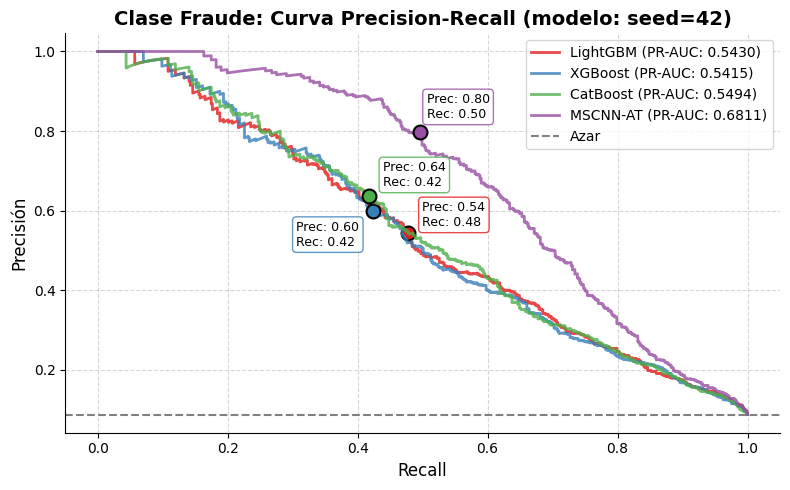

In [7]:
def plot_pr_curve(y_test, probs_dict, thresholds_dict):
    plt.figure(figsize=(8, 5))
    palette = sns.color_palette("Set1", len(probs_dict))
    colors = {name: palette[i] for i, name in enumerate(probs_dict)}
    label_offsets = {
        'LightGBM': (10, 5),
        'XGBoost': (-55, -25),
        'CatBoost': (10, 7),
        'MSCNN-AT': (5, 10),
    }

    for name, probs in probs_dict.items():
        precision, recall, pr_thresholds = precision_recall_curve(y_test, probs)
        plt.plot(
            recall,
            precision,
            label=f'{name} (PR-AUC: {average_precision_score(y_test, probs):.4f})',
            color=colors[name],
            linewidth=2,
            alpha=0.8,
        )

        chosen_th = thresholds_dict[name]
        idx = np.argmin(np.abs(pr_thresholds - chosen_th))
        plt.plot(
            recall[idx],
            precision[idx],
            marker='o',
            markersize=10,
            markeredgecolor='black',
            markeredgewidth=1.5,
            color=colors[name],
        )
        plt.annotate(
            f"Prec: {precision[idx]:.2f}\nRec: {recall[idx]:.2f}",
            (recall[idx], precision[idx]),
            textcoords="offset points",
            xytext=label_offsets.get(name, (10, 5)),
            ha='left',
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=colors[name], alpha=0.8),
        )

    baseline = y_test.mean()
    plt.axhline(
        baseline,
        color='gray',
        linestyle='--',
        label=f'Azar',
    )

    plt.title('Clase Fraude: Curva Precision-Recall (modelo: seed=42)', fontsize=14, fontweight='semibold')
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precisión', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.5)
    sns.despine()
    plt.tight_layout()
    plt.show()


y_test_tabular = test_xgb['FLAG'].to_numpy()

probs_dict = {
    'LightGBM': test_probs_lgbm,
    'XGBoost': test_probs_xgb,
    'CatBoost': test_probs_cat,
    'MSCNN-AT': test_probs_dl,
}
thresholds_dict = {
    'LightGBM': th_lgbm,
    'XGBoost': th_xgb,
    'CatBoost': th_cat,
    'MSCNN-AT': th_dl,
}
plot_pr_curve(y_test_tabular, probs_dict, thresholds_dict)


## 2. Histograma vs otros estudios

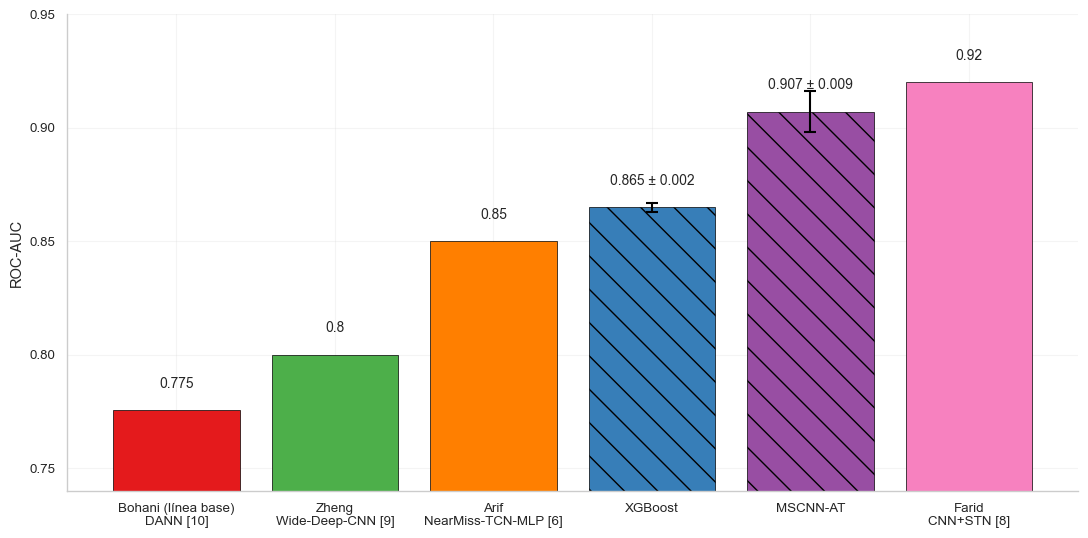

In [8]:
# Datos
df_plot = pd.DataFrame({
    'Modelo': [
        'Bohani (línea base)\nDANN [10]',
        'Zheng\nWide-Deep-CNN [9]',
        'Arif\nNearMiss-TCN-MLP [6]',
        'XGBoost',
        'MSCNN-AT',
        'Farid\nCNN+STN [8]',
    ],
    'AUC': [0.7754, 0.8, 0.850, 0.865, 0.907, 0.920],
    'Error': [0, 0, 0, 0.002, 0.009, 0],
    'Tipo': ['_', '_', '_', 'Propio', 'Propio', '_']
})


sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

palette = sns.color_palette("Set1", 8)
# Colores manteniendo el Set 1 de la anterior figura
colors = [
    palette[0],   # Bohani
    palette[2],   # Zheng
    palette[4],   # Arif
    palette[1],   # XGBoost
    palette[3],   # MSCNN-AT
    palette[7]    # Farid
]

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.bar(
    x=df_plot['Modelo'],
    height=df_plot['AUC'],
    color=colors,
    edgecolor='black',
    linewidth=0.5
)

# Textura en los modelos propios
for i, bar in enumerate(bars):
    if df_plot.iloc[i]['Tipo'] == 'Propio':
        bar.set_hatch('\\')

# Barras de error
for i, row in df_plot.iterrows():
    if row['Error'] > 0:
        ax.errorbar(
            x=i,
            y=row['AUC'],
            yerr=row['Error'],
            ecolor='black',
            elinewidth=1.5,
            capsize=4,
            capthick=1.5
        )

# Etiquetas superiores
for i, row in df_plot.iterrows():
    text = f"{row['AUC']:.3g}"
    if row['Error'] > 0:
        text += f" ± {row['Error']:.3f}"
    ax.text(
        i,
        row['AUC'] + 0.01,
        text,
        ha='center',
        fontsize=10
    )

ax.set_ylabel('ROC-AUC')
ax.set_xlabel('')
ax.set_ylim(0.74, 0.95)
ax.set_yticks([0.75, 0.80, 0.85, 0.90, 0.95])
ax.grid(alpha=0.2)
sns.despine(left=False, bottom=False)
plt.tight_layout()
plt.show()

## 3. Tiempos de ejecución

In [9]:
import time

time_xgb = []
for i in range(5):
    start_time = time.time()
    test_probs_xgb = model_xgb.predict_proba(test_xgb.drop(columns=['FLAG']))[:, 1]
    end_time = time.time()
    total_time = end_time - start_time
    num_samples = test_xgb.shape[0]
    time_per_inference = total_time / num_samples
    time_xgb.append(time_per_inference)
    print(f"Iteración {i+1}: {time_per_inference:.6f} segundos")

mean_time_xgb = np.mean(time_xgb)
std_time_xgb = np.std(time_xgb)
print(f"Tiempo medio por inferencia XGBoost: {mean_time_xgb:.6f} segundos ± {std_time_xgb:.6f} segundos")

time_dl = []
for i in range(5):
    start_time = time.time()
    test_probs_dl = dl_model.predict(X_test_dl, verbose=0).ravel()
    end_time = time.time()
    total_time = end_time - start_time
    num_samples = X_test_dl.shape[0]
    time_per_inference = total_time / num_samples
    time_dl.append(time_per_inference)
    print(f"Iteración {i+1}: {time_per_inference:.6f} segundos")

mean_time_dl = np.mean(time_dl)
std_time_dl = np.std(time_dl)
print(f"Tiempo medio por inferencia MSCNN-AT: {mean_time_dl:.6f} segundos ± {std_time_dl:.6f} segundos")

Iteración 1: 0.000007 segundos
Iteración 2: 0.000005 segundos
Iteración 3: 0.000006 segundos
Iteración 4: 0.000006 segundos
Iteración 5: 0.000005 segundos
Tiempo medio por inferencia XGBoost: 0.000006 segundos ± 0.000001 segundos
Iteración 1: 0.000627 segundos
Iteración 2: 0.000615 segundos
Iteración 3: 0.000624 segundos
Iteración 4: 0.000608 segundos
Iteración 5: 0.000607 segundos
Tiempo medio por inferencia MSCNN-AT: 0.000616 segundos ± 0.000008 segundos


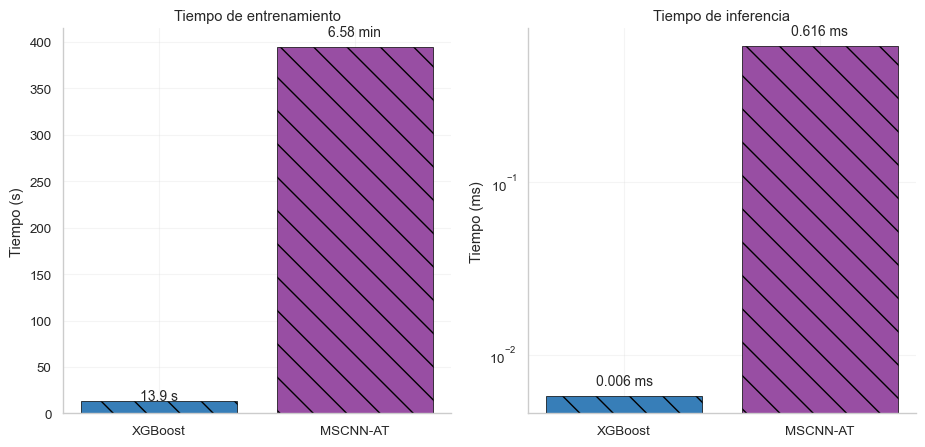

In [10]:
# Entrenamiento
train_models = ['XGBoost', 'MSCNN-AT']
train_times = [
    13.92,
    6.58 * 60
]

# Inferencia en ms
infer_models = ['XGBoost', 'MSCNN-AT']
infer_times = [mean_time_xgb * 1000, mean_time_dl * 1000]
infer_errors = [std_time_xgb * 1000, std_time_dl * 1000]
colors = [palette[1], palette[3]]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Tiempo entreno
ax = axes[0]
bars = ax.bar(
    train_models,
    train_times,
    color=colors,
    edgecolor='black',
    linewidth=0.5
)
labels_train = ["13.9 s", "6.58 min"]

for i, bar in enumerate(bars):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() * 1.03,
        labels_train[i],
        bars[i].set_hatch('\\'),
        ha='center',
        fontsize=10
    )

ax.set_title('Tiempo de entrenamiento')
ax.set_ylabel('Tiempo (s)')
ax.grid(alpha=0.2)

# Inferencia
ax = axes[1]
bars = ax.bar(
    infer_models,
    infer_times,
    color=colors,
    edgecolor='black',
    linewidth=0.5
)

# Etiquetas
for i, value in enumerate(infer_times):
    text = f"{value:.3f} ms"
    ax.text(
        i,
        value * 1.15,
        text,
        bars[i].set_hatch('\\'),
        ha='center',
        fontsize=10
    )

ax.set_title('Tiempo de inferencia')
ax.set_ylabel('Tiempo (ms)')
ax.set_yscale('log')
ax.grid(alpha=0.2)
sns.despine(left=False, bottom=False)
plt.show()

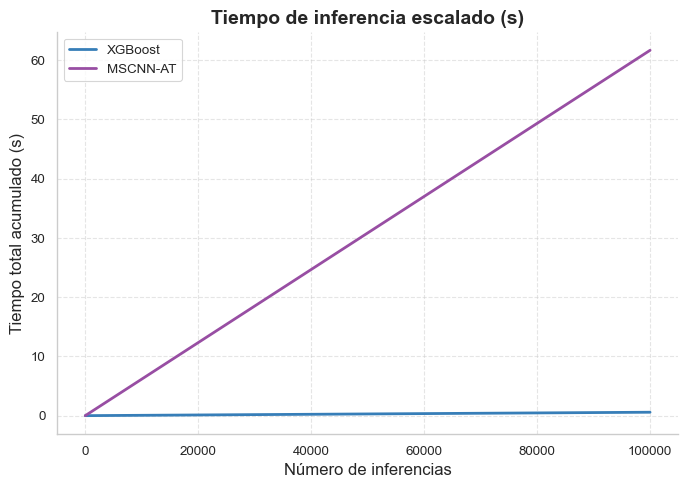

In [11]:
# Escalado de la inferencia
n_samples = np.arange(1, 100_001)
xgb_total = mean_time_xgb * n_samples
mscnn_total = mean_time_dl * n_samples

plt.figure(figsize=(7, 5))
plt.plot(xgb_total, label='XGBoost', color=palette[1], linewidth=2)
plt.plot(mscnn_total, label='MSCNN-AT', color=palette[3], linewidth=2)
plt.title('Tiempo de inferencia escalado (s)', fontsize=14, fontweight='semibold')
plt.xlabel('Número de inferencias', fontsize=12)
plt.ylabel('Tiempo total acumulado (s)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

## 4. Resumen métodos *resampling*

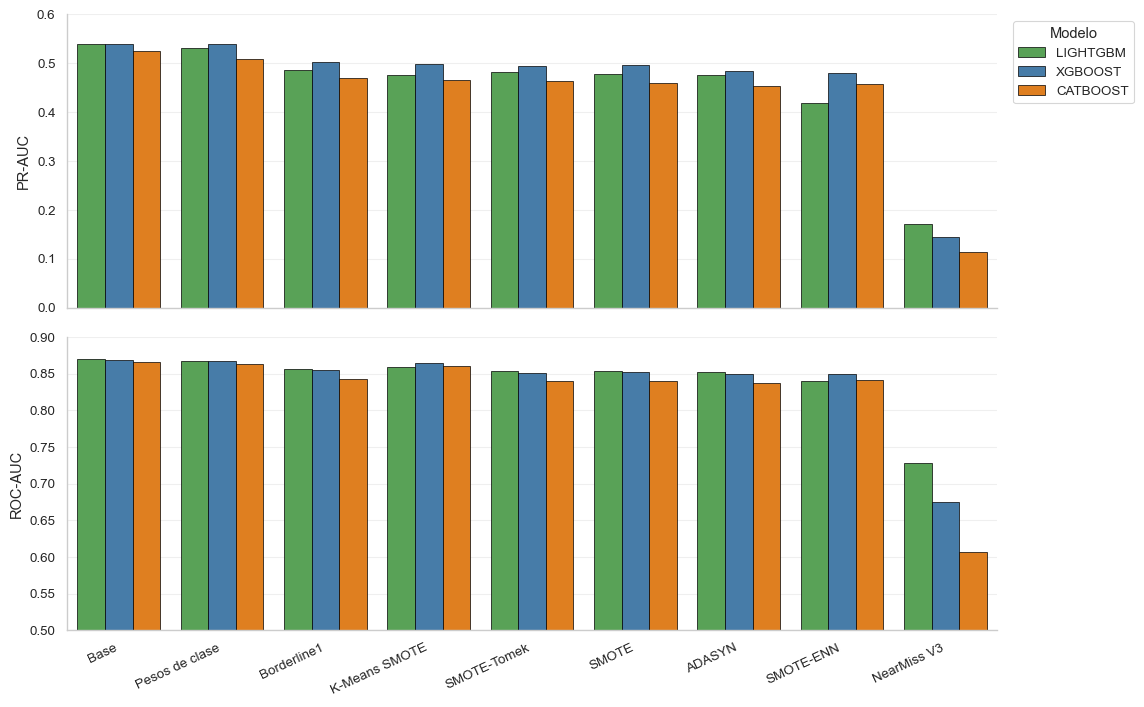

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io

# Datos de 03_ML_modeling.ipynb (se cambian algunos nombres a castellano)
data = """Model	Strategy	PR_AUC_mean	ROC_AUC_mean
LIGHTGBM	Base	0.539124	0.870331
LIGHTGBM	Pesos de clase	0.530603	0.867431
LIGHTGBM	Borderline1	0.485267	0.856070
LIGHTGBM	SMOTE-Tomek	0.481374	0.853842
LIGHTGBM	SMOTE	0.478642	0.853836
LIGHTGBM	K-Means SMOTE	0.476899	0.859696
LIGHTGBM	ADASYN	0.475391	0.851700
LIGHTGBM	SMOTE-ENN	0.418862	0.840394
LIGHTGBM	NearMiss V3	0.171251	0.728355
XGBOOST	Pesos de clase	0.540066	0.866954
XGBOOST	Base	0.539992	0.868988
XGBOOST	Borderline1	0.502005	0.854976
XGBOOST	K-Means SMOTE	0.498685	0.864706
XGBOOST	SMOTE	0.495901	0.852394
XGBOOST	SMOTE-Tomek	0.494674	0.851114
XGBOOST	ADASYN	0.484538	0.849727
XGBOOST	SMOTE-ENN	0.480172	0.849030
XGBOOST	NearMiss V3	0.143814	0.674338
CATBOOST	Base	0.525880	0.865639
CATBOOST	Pesos de clase	0.508931	0.862495
CATBOOST	Borderline1	0.469332	0.842215
CATBOOST	K-Means SMOTE	0.465601	0.859842
CATBOOST	SMOTE-Tomek	0.462931	0.840441
CATBOOST	SMOTE	0.459432	0.839350
CATBOOST	SMOTE-ENN	0.457495	0.841986
CATBOOST	ADASYN	0.453027	0.837076
CATBOOST	NearMiss V3	0.114121	0.607064"""

df = pd.read_csv(io.StringIO(data), sep='\t')

# Orden por PR-AUC
order_strategies = df.groupby('Strategy')['PR_AUC_mean'].mean().sort_values(ascending=False).index

# Estilos y plot
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
palette = sns.color_palette("Set1", 8)
model_colors = {
    'LIGHTGBM': palette[2],
    'XGBOOST': palette[1],
    'CATBOOST': palette[4]
}
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'hspace': 0.1})
sns.barplot(
    data=df, x='Strategy', y='PR_AUC_mean', hue='Model',
    ax=axes[0], palette=model_colors, order=order_strategies,
    edgecolor='black', linewidth=0.5
)
axes[0].set_ylabel('PR-AUC')
axes[0].set_ylim(0, 0.6)
axes[0].legend(title='Modelo', bbox_to_anchor=(1.01, 1), loc='upper left')

sns.barplot(
    data=df, x='Strategy', y='ROC_AUC_mean', hue='Model',
    ax=axes[1], palette=model_colors, order=order_strategies,
    edgecolor='black', linewidth=0.5
)
axes[1].set_ylabel('ROC-AUC')
axes[1].set_xlabel('')
axes[1].set_ylim(0.5, 0.9)
axes[1].get_legend().remove()

for ax in axes:
    ax.grid(axis='y', alpha=0.3)
    ax.grid(axis='x', visible=False)

sns.despine(left=False, bottom=False)
plt.xticks(rotation=25, ha='right')
plt.show()

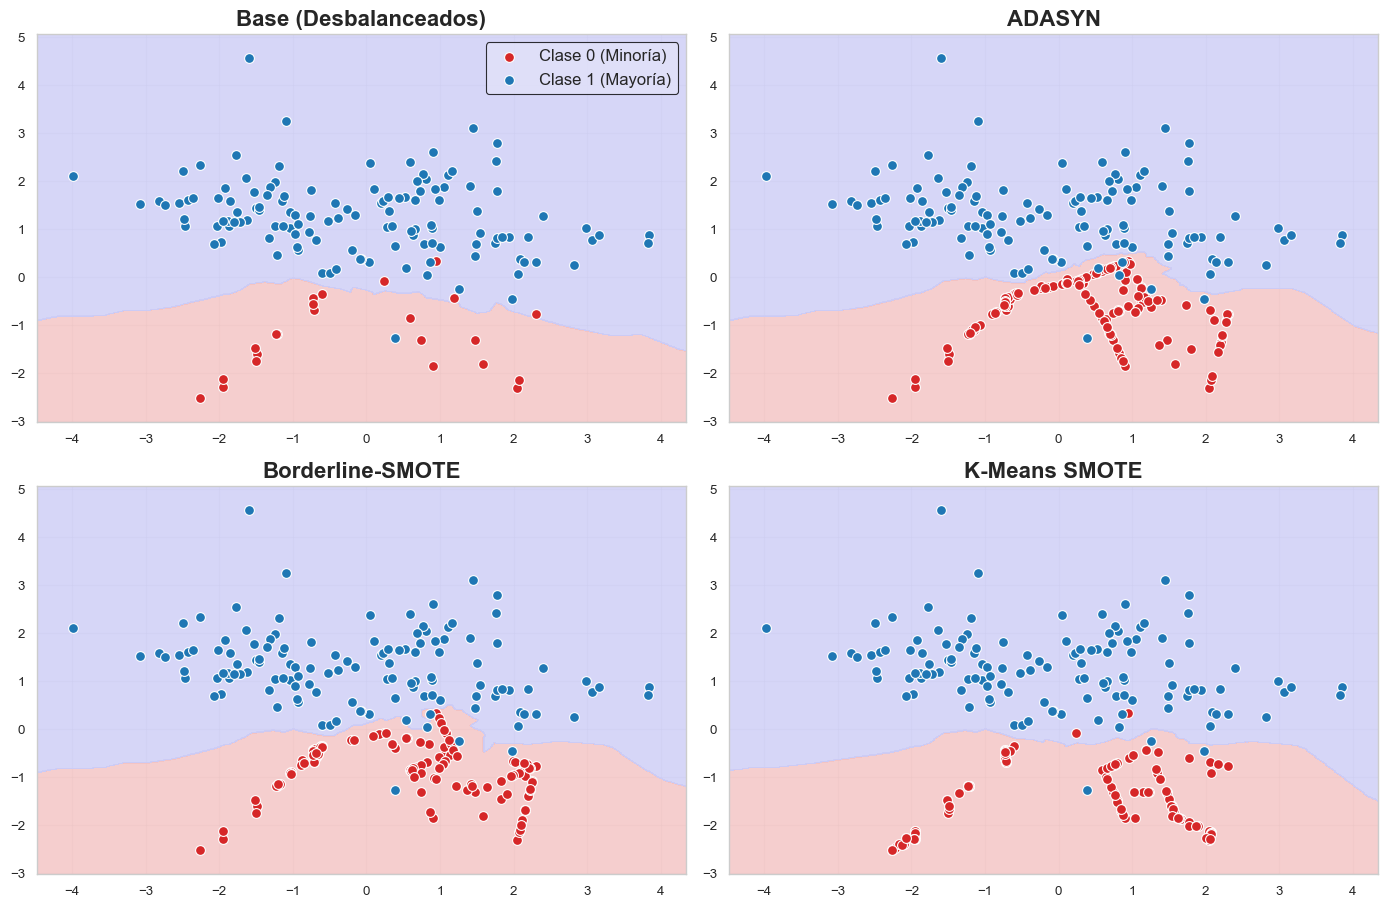

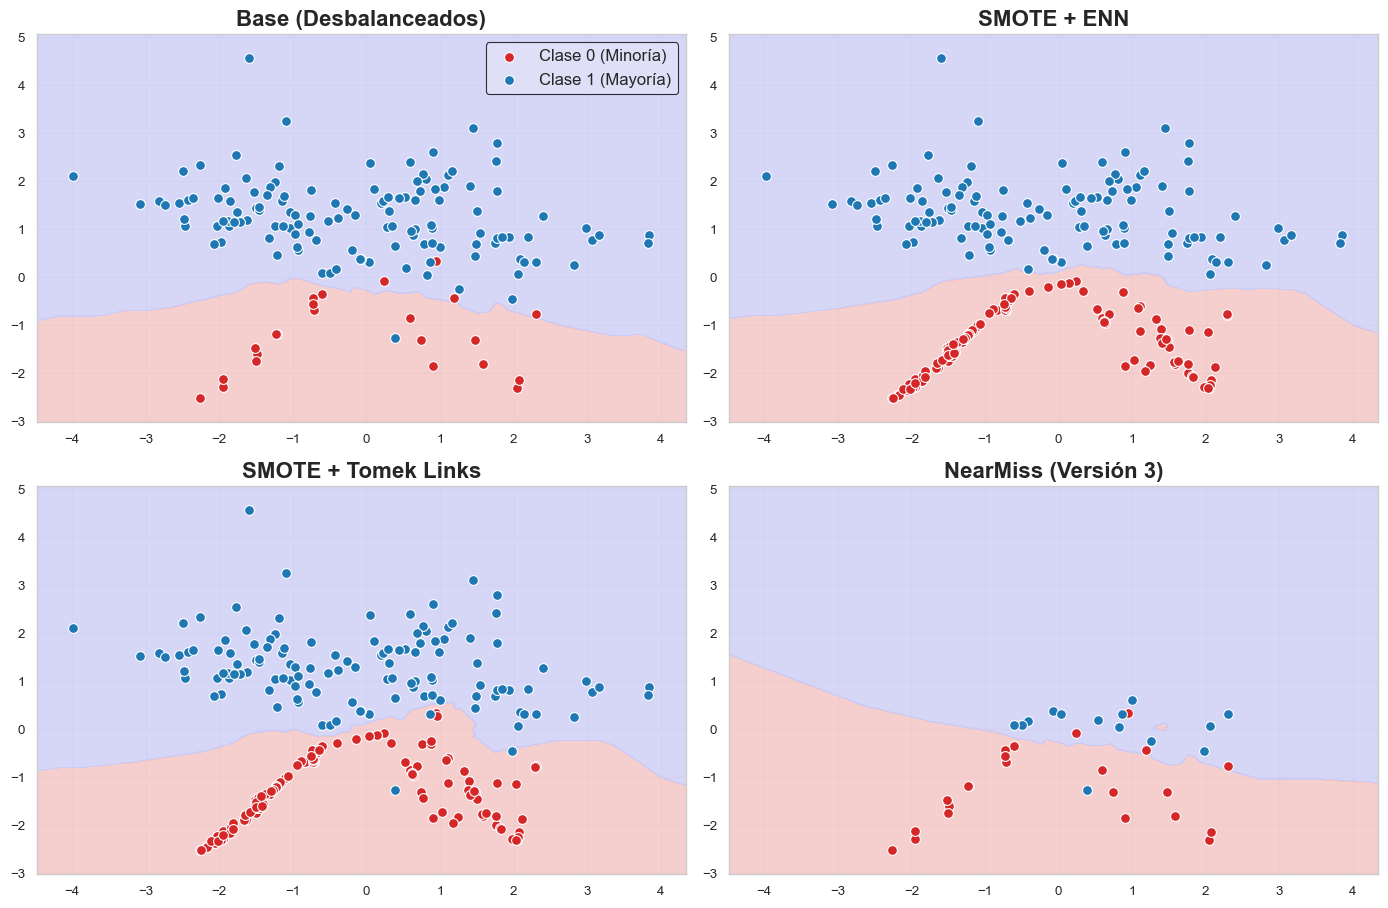

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import ADASYN, BorderlineSMOTE, KMeansSMOTE
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.under_sampling import NearMiss
import warnings
warnings.filterwarnings("ignore")

# Dataset desbalanceado
X, y = make_classification(
    n_classes=2, class_sep=1.2, weights=[0.15, 0.85], 
    n_informative=2, n_redundant=0, flip_y=0, 
    n_features=2, n_clusters_per_class=2, 
    n_samples=150, random_state=SEED
)

# Clasificador KNN
clf_base = KNeighborsClassifier(n_neighbors=3)

# Plots
def plot_decision_boundary(X_res, y_res, ax, title, legend=False):
    clf = KNeighborsClassifier(n_neighbors=3)
    clf.fit(X_res, y_res)
    
    # Escalas
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    # Predicción frontera
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Color de fondo
    cmap_light = ListedColormap(["#f3c2c2", "#ccccf6"])
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=cmap_light)
    
    # Scatter de los puntos
    ax.scatter(X_res[y_res==0, 0], X_res[y_res==0, 1], 
               c='#d62728', label='Clase 0 (Minoría)', edgecolor='w', s=50, zorder=3)
    ax.scatter(X_res[y_res==1, 0], X_res[y_res==1, 1], 
               c='#1f77b4', label='Clase 1 (Mayoría)', edgecolor='w', s=50, zorder=3)
    
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.grid(True, alpha=0.4, linestyle='-')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    if ax.get_legend_handles_labels()[0] and legend:
        ax.legend(loc='upper right', fontsize=12, frameon=True, edgecolor='black', facecolor="#e2e2f9")

# Figura 1
fig1, axes1 = plt.subplots(2, 2, figsize=(14, 10))
plot_decision_boundary(X, y, axes1[0, 0], "Base (Desbalanceados)", legend=True)
adasyn = ADASYN(random_state=SEED)
X_ada, y_ada = adasyn.fit_resample(X, y)
plot_decision_boundary(X_ada, y_ada, axes1[0, 1], "ADASYN")
bsmote = BorderlineSMOTE(random_state=SEED)
X_bsmote, y_bsmote = bsmote.fit_resample(X, y)
plot_decision_boundary(X_bsmote, y_bsmote, axes1[1, 0], "Borderline-SMOTE")
kmsmote = KMeansSMOTE(random_state=SEED, cluster_balance_threshold=0.01)
X_kms, y_kms = kmsmote.fit_resample(X, y)
plot_decision_boundary(X_kms, y_kms, axes1[1, 1], "K-Means SMOTE")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Figura 2
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10))
plot_decision_boundary(X, y, axes2[0, 0], "Base (Desbalanceados)", legend=True)
smote_enn = SMOTEENN(random_state=SEED)
X_senn, y_senn = smote_enn.fit_resample(X, y)
plot_decision_boundary(X_senn, y_senn, axes2[0, 1], "SMOTE + ENN")
smote_tomek = SMOTETomek(random_state=SEED)
X_stomek, y_stomek = smote_tomek.fit_resample(X, y)
plot_decision_boundary(X_stomek, y_stomek, axes2[1, 0], "SMOTE + Tomek Links")
nm3 = NearMiss(version=3)
X_nm3, y_nm3 = nm3.fit_resample(X, y)
plot_decision_boundary(X_nm3, y_nm3, axes2[1, 1], "NearMiss (Versión 3)")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()